<a href="https://colab.research.google.com/github/Kusuma-1309/Neural-Networks-and-Deep-Learning/blob/main/Expt_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Archive:  archive.csv.zip
  inflating: credit_card_fraud_10k.csv  
Dataset shape: (20000, 9)
is_fraud
0    19698
1      302
Name: count, dtype: int64
Class Weights: {0: 1.0, 1: np.float64(65.11570247933884)}
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - auc: 0.5378 - loss: 1.4884 - precision: 0.0340 - recall: 0.2735 - val_auc: 0.9621 - val_loss: 0.5432 - val_precision: 0.0638 - val_recall: 0.9535
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9611 - loss: 0.8491 - precision: 0.0808 - recall: 0.9713 - val_auc: 0.9762 - val_loss: 0.3817 - val_precision: 0.0909 - val_recall: 1.0000
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.9718 - loss: 0.5966 - precision: 0.1058 - recall: 0.9617 - val_auc: 0.9812 - val_loss: 0.2690 - val_precision: 0.1097 - val_recall: 1.0000
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9838 - loss: 0.4289 - precision: 0.1330 - recall: 0.9849 - val_auc: 0.9847 - val_loss: 0.2259 - val_precision: 0.1225 - val_recall: 1.0000
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.9873 - loss: 0.3409 - precision: 0.1464 - recall: 0.9777 - val_auc: 0.9867 - val_loss: 0.1903 - val_precision: 0.1438 - val_recall: 1.0000
Epoch 6/10
50/50 ━━━

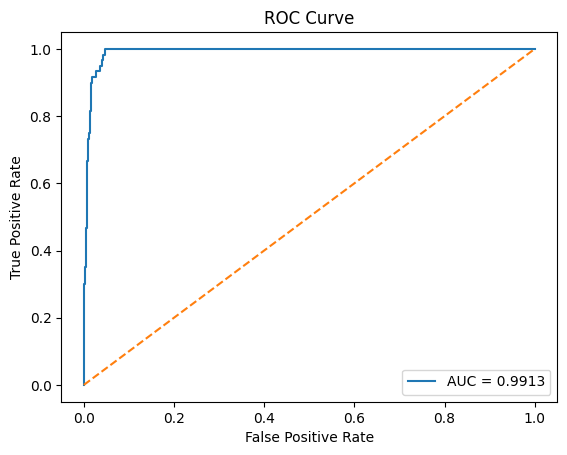

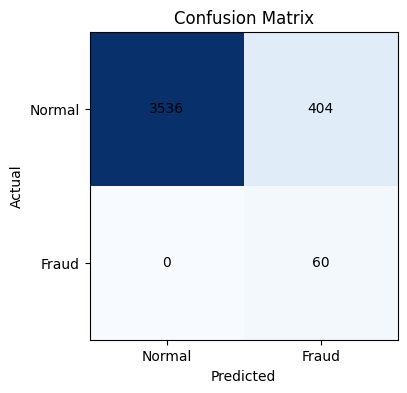

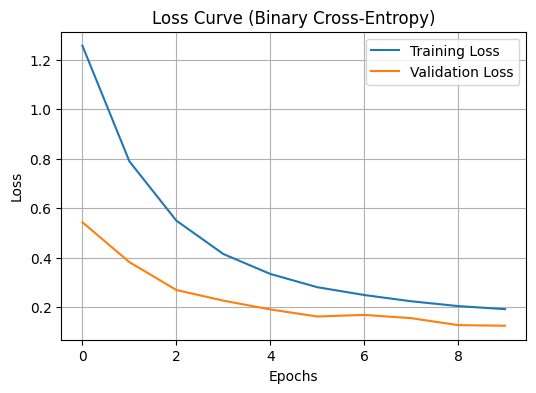

In [4]:
# ============================
# CREDIT CARD FRAUD DETECTION
# ============================

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ----------------------------
# 1. UNZIP DATASET
# ----------------------------
!unzip -o archive.csv.zip

# ----------------------------
# 2. LOAD TRAIN & TEST FILES
# ----------------------------
train_df = pd.read_csv("/content/credit_card_fraud_10k.csv", encoding="latin1")
test_df  = pd.read_csv("/content/credit_card_fraud_10k.csv", encoding="latin1")

# ----------------------------
# 3. COMBINE DATA
# ----------------------------
df = pd.concat([train_df, test_df], ignore_index=True)

# Keep only numeric columns
df = df.select_dtypes(include=[np.number])
df = df.fillna(0)

print("Dataset shape:", df.shape)
print(df['is_fraud'].value_counts())

# ----------------------------
# 4. FEATURES & LABEL
# ----------------------------
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# ----------------------------
# 5. TRAIN-TEST SPLIT
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ----------------------------
# 6. FEATURE SCALING
# ----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------
# 7. HANDLE CLASS IMBALANCE
# ----------------------------
neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: neg / max(pos, 1)}
print("Class Weights:", class_weight)

# ----------------------------
# 8. BUILD MODEL
# ----------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# ----------------------------
# 9. COMPILE MODEL
# LOSS FUNCTION: Binary Crossentropy
# ----------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# ----------------------------
# 10. TRAIN MODEL (SAVE HISTORY)
# ----------------------------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight,
    verbose=1
)

# ----------------------------
# 11. PREDICT PROBABILITIES
# ----------------------------
y_prob = model.predict(X_test).ravel()

# ----------------------------
# 12. APPLY THRESHOLD
# ----------------------------
THRESHOLD = 0.2 # fraud-friendly threshold
y_pred = (y_prob >= THRESHOLD).astype(int)

# ----------------------------
# 13. CONFUSION MATRIX
# ----------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# 14. CLASSIFICATION REPORT
# ----------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ----------------------------
# 15. ROC CURVE
# ----------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ----------------------------
# 16. CONFUSION MATRIX PLOT
# ----------------------------
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.yticks([0,1], ['Normal', 'Fraud'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------
# 17. LOSS CURVE (TRAIN vs VALIDATION)
# ----------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve (Binary Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.show()
